## 1. Setup — Import Libraries & Load Data

In [22]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import roc_curve

In [19]:
try:
    X_train = joblib.load("X_train.pkl")
    X_test = joblib.load("X_test.pkl")
    y_train = joblib.load("y_train.pkl")
    y_test = joblib.load("y_test.pkl")
except FileNotFoundError as e:
    print(f"Error: pickle file not found — {e}")
else:
    print("Loaded successfully")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_test :", X_test.shape, "y_test :", y_test.shape)

Loaded successfully
X_train: (3996, 42) y_train: (3996,)
X_test : (1000, 42) y_test : (1000,)


## 2. Baseline Model
An ANN model is developed using arbitrary hyperparameters before applying hyperparameter tuning. This provides a benchmark for comparing the optimized model.

In [20]:
ann = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

ann.fit(X_train, y_train)

ann_pred = ann.predict(X_test)
ann_accuracy = accuracy_score(y_test, ann_pred)

print("Baseline Accuracy:", ann_accuracy)
print(classification_report(y_test, ann_pred))

Baseline Accuracy: 0.775
              precision    recall  f1-score   support

           0       0.77      0.69      0.73       438
           1       0.78      0.84      0.81       562

    accuracy                           0.78      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.78      0.77      1000



## 3. Hyperparameter Tuning 
Grid Search is used to determine the optimal combination of hyperparameters, including learning rate, regularization (alpha), and early stopping, to improve the predictive performance of the ANN model.

In [16]:
param_grid = {
    "hidden_layer_sizes": [(64, 32)],
    "activation": ["relu"],
    "learning_rate_init": [0.001, 0.002, 0.005],
    "alpha": [0.0001, 0.001],
    "solver": ["adam"],
    "early_stopping": [True, False]
}

grid_search = GridSearchCV(
    estimator=MLPClassifier(max_iter=3000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_ann = grid_search.best_estimator_

print("========== Best Hyperparameters ==========")
print(grid_search.best_params_)
print("\nBest Cross Validation Accuracy:")
print(f"{grid_search.best_score_:.4f}")

========== Best Hyperparameters ==========
{'activation': 'relu', 'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'solver': 'adam'}

Best Cross Validation Accuracy:
0.8018


## 4. Best Model Evaluation
The optimized ANN model obtained from Grid Search is evaluated on the test set, including a training-vs-testing accuracy comparison to check for overfitting or underfitting.

In [17]:
best_pred = best_ann.predict(X_test)

train_accuracy = best_ann.score(X_train, y_train)
test_accuracy = best_ann.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)
print()
print(classification_report(y_test, best_pred))

Training Accuracy: 0.8215715715715716
Testing Accuracy: 0.788

              precision    recall  f1-score   support

           0       0.76      0.76      0.76       438
           1       0.81      0.81      0.81       562

    accuracy                           0.79      1000
   macro avg       0.78      0.79      0.78      1000
weighted avg       0.79      0.79      0.79      1000



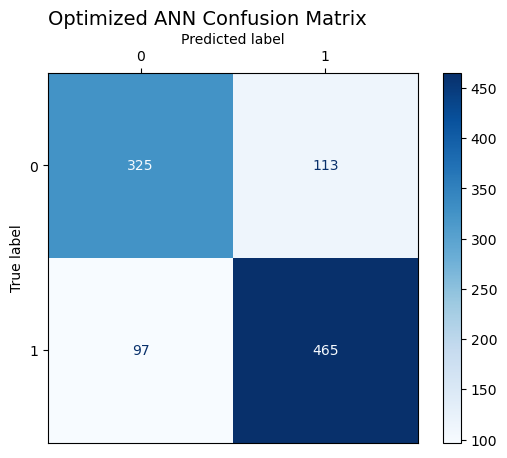

In [15]:
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.gca().xaxis.tick_top()
plt.gca().xaxis.set_label_position("top")
plt.title("Optimized ANN Confusion Matrix", fontsize=14, loc='left')
plt.xlabel("Predicted label", fontsize=10)
plt.ylabel("True label", fontsize=10)

plt.show()

## 5. Model Stability — Cross-Validation 
5-fold cross-validation is performed to evaluate the stability and generalization performance of the optimized ANN model.

[0.8075     0.78973717 0.79724656 0.81602003 0.79849812]
Average CV Accuracy: 0.8018003754693366


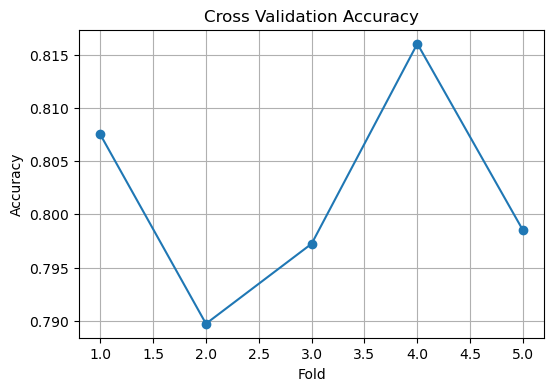

In [7]:
cv_scores = cross_val_score(best_ann, X_train, y_train, cv=5, scoring="accuracy")

print(cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

plt.figure(figsize=(6, 4))
plt.plot(range(1, 6), cv_scores, marker="o")
plt.title("Cross Validation Accuracy")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

## 6. Youden's J Statistic

In [23]:
# get predicted probabilities (not just 0/1 labels)
y_probs = best_ann.predict_proba(X_test)[:, 1]

# calculate the ROC curve: false positive rate, true positive rate, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Youden's J statistic = sensitivity + specificity - 1 = tpr - fpr
j_scores = tpr - fpr
best_threshold_idx = np.argmax(j_scores)
best_threshold = thresholds[best_threshold_idx]

print(f"Optimal threshold: {best_threshold:.4f}")
print(f"Youden's J at this threshold: {j_scores[best_threshold_idx]:.4f}")

# apply the new threshold instead of the default 0.5
y_pred_optimal = (y_probs >= best_threshold).astype(int)

from sklearn.metrics import accuracy_score, classification_report
print("\\nAccuracy with optimal threshold:", accuracy_score(y_test, y_pred_optimal))
print(classification_report(y_test, y_pred_optimal))

Optimal threshold: 0.6398
Youden's J at this threshold: 0.5895
\nAccuracy with optimal threshold: 0.786
              precision    recall  f1-score   support

           0       0.71      0.87      0.78       438
           1       0.87      0.72      0.79       562

    accuracy                           0.79      1000
   macro avg       0.79      0.79      0.79      1000
weighted avg       0.80      0.79      0.79      1000



## 7. Training Diagnostics — Loss Curve & Convergence
The loss curve shows how training loss changes during learning — a decreasing curve indicates the ANN is learning and converging properly. The number of iterations and final loss confirm convergence.

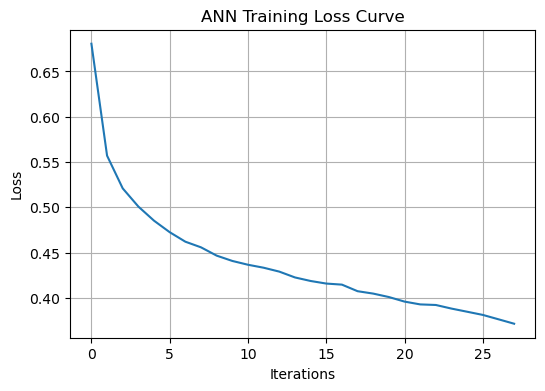

Number of Iterations: 28
Final Loss: 0.37155277303210266


In [8]:
plt.figure(figsize=(6, 4))
plt.plot(best_ann.loss_curve_)
plt.title("ANN Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

print("Number of Iterations:", best_ann.n_iter_)
print("Final Loss:", best_ann.loss_)

## 8. Result Summary & Save Model

In [9]:
report = classification_report(y_test, best_pred, output_dict=True)

summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Train-Test Gap"],
    "Value": [
        accuracy_score(y_test, best_pred),
        report["weighted avg"]["precision"],
        report["weighted avg"]["recall"],
        report["weighted avg"]["f1-score"],
        train_accuracy - test_accuracy
    ]
})

summary

,Metric,Value
0,Accuracy,0.788000
1,Precision,0.788232
2,Recall,0.788000
3,F1-score,0.788103
4,Train-Test Gap,0.033572


In [10]:
# save the trained model
joblib.dump(best_ann, 'ann_model.pkl')
print("Model saved successfully!")

Model saved successfully!
